# Interactive Algorithm Visualization: Petersen Graph Coloring

This notebook demonstrates the interactive visualization GUI for algorithm search trajectories on the Petersen graph 3-coloring problem.

**Features:**
- Live algorithm execution with trajectory callback
- Interactive slider to scrub through the algorithm's search path
- Petersen graph visualization with vertex colorings at each step
- Instantaneous regret curve overlay
- Constraint validation (conflicts, unassigned vertices)

## 1. Setup Notebook Environment

First, we import the necessary libraries and verify versions.

In [ ]:
# Import Regret components
from regret.algorithms.local_search import RLS
from regret.gui import InteractiveTrajectoryViewer, PetersenGraphVisualizer, TrajectoryBuffer
from regret.problems.combinatorial import PetersenColoringMaxSAT

Python version: 3.12.12 (main, Oct 28 2025, 12:10:49) [Clang 20.1.4 ]
NumPy version: 2.4.0
✓ All imports successful!


## 2. Configuration

Define the algorithm and problem configuration for this demo.

In [7]:
# Configuration parameters
config = {
    "problem": "PetersenColoringMaxSAT",
    "algorithm": "RLS",
    "budget": 100,  # Number of function evaluations
    "seed": 42,  # For reproducibility
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  problem: PetersenColoringMaxSAT
  algorithm: RLS
  budget: 100
  seed: 42


## 3. Initialize Problem and Run Algorithm with Callback

Create the Petersen graph problem and run RLS with a trajectory buffer to record the search history.

In [8]:
# Initialize the problem
problem = PetersenColoringMaxSAT()
print("Problem: Petersen graph 3-coloring")
print(f"  Dimension (n): {problem.n}")
print(f"  Optimum value (f_star): {problem.f_star}")

# Create trajectory buffer to record algorithm steps
trajectory = TrajectoryBuffer()


# Define callback function to feed into trajectory buffer
def record_trajectory(evals, current_value, best_value, solution):
    """Callback invoked at each algorithm step."""
    trajectory.record(evals, current_value, best_value, solution)


# Initialize and run the algorithm with callback
algo = RLS(problem, seed=config["seed"], callback=record_trajectory)
best_value, best_solution = algo.run(budget=config["budget"])

print(f"\nAlgorithm: {config['algorithm']} (Randomized Local Search)")
print(f"  Budget: {config['budget']} evaluations")
print(f"  Best value found: {best_value:.1f}")
print(f"  Trajectory length: {len(trajectory)} steps")
print(" Algorithm execution complete!")

Problem: Petersen graph 3-coloring
  Dimension (n): 30
  Optimum value (f_star): 85.0

Algorithm: RLS (Randomized Local Search)
  Budget: 100 evaluations
  Best value found: 84.0
  Trajectory length: 101 steps
 Algorithm execution complete!


## 4. Validate and Inspect Final Solution

Check the quality of the final solution and validate the coloring against Petersen graph constraints.

In [9]:
# Validate final solution
visualizer = PetersenGraphVisualizer(problem)
validation = visualizer.validate_coloring(best_solution)  # type: ignore[arg-type]

print("Final solution validation:")
print(f"  Valid coloring: {validation['valid']}")
print(f"  Unassigned vertices: {len(validation['unassigned_vertices'])}")
print(f"  Constraint conflicts: {len(validation['conflicts'])}")

# Show trajectory statistics
evals = trajectory.get_evaluation_counts()
best_vals = trajectory.get_best_values()
print("\nTrajectory statistics:")
print(f"  Min evaluations: {evals.min()}")
print(f"  Max evaluations: {evals.max()}")
print(f"  Initial best value: {best_vals[0]:.1f}")
print(f"  Final best value: {best_vals[-1]:.1f}")
print(f"  Improvement: {best_vals[-1] - best_vals[0]:.1f}")

Final solution validation:
  Valid coloring: False
  Unassigned vertices: 0
  Constraint conflicts: 1

Trajectory statistics:
  Min evaluations: 1
  Max evaluations: 100
  Initial best value: 61.0
  Final best value: 84.0
  Improvement: 23.0


## 5. Interactive Trajectory Viewer

Use the slider below to scrub through the algorithm's search trajectory. The left panel shows the Petersen graph with vertex colorings, while the right panel shows the instantaneous regret curve with the current step marked.

IntSlider(value=0, continuous_update=False, description='Step:')

Output()

Output()

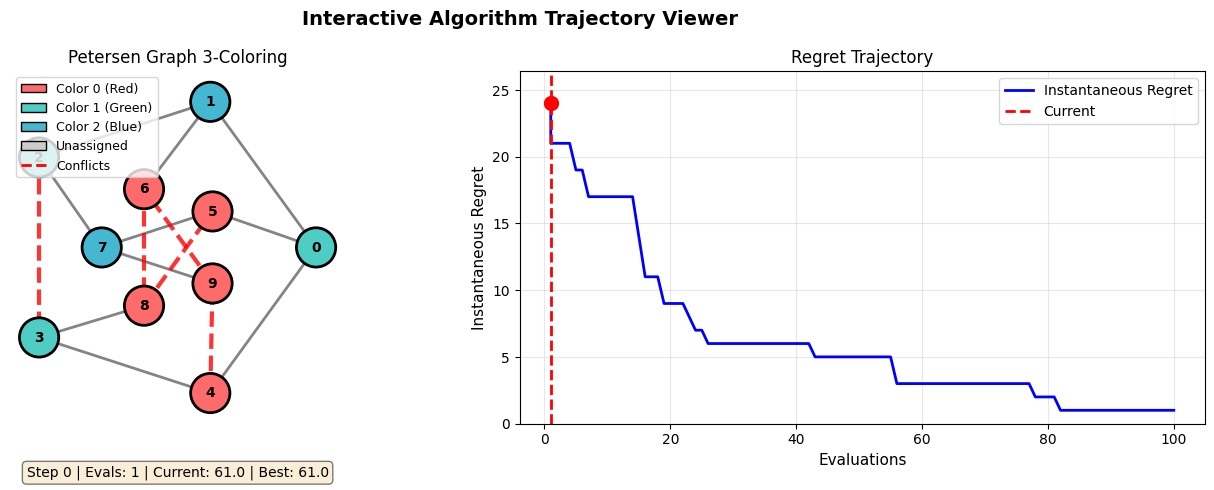

In [13]:
# Create and display the interactive viewer
viewer = InteractiveTrajectoryViewer(trajectory, problem)

# Show the interactive widget with slider and plots
# Note: This requires Jupyter notebook environment with ipywidgets and matplotlib
viewer.show()

# print("\n Interactive viewer created successfully!")
# print("Use the slider above to navigate through the algorithm's search trajectory.")

## 6. Usage Notes

### Using with Different Algorithms

This framework works with any algorithm that subclasses `Algorithm`. Simply create a callback function and pass it during initialization:

```python
from regret.algorithms.evolutionary import OnePlusOneEA
buffer = TrajectoryBuffer()
algo = OnePlusOneEA(problem, callback=lambda e, c, b, s: buffer.record(e, c, b, s))
algo.run(budget=100)
viewer = InteractiveTrajectoryViewer(buffer, problem)
viewer.show()
```

### Key Components

- **TrajectoryBuffer**: Accumulates algorithm state at each step via callback
- **PetersenGraphVisualizer**: Renders Petersen graph with colored vertex assignments
- **InteractiveTrajectoryViewer**: Creates an interactive Jupyter widget with slider and plots

### Extending to Other Problems

To visualize other combinatorial problems:
1. Create a custom visualizer that inherits or follows the `PetersenGraphVisualizer` pattern
2. Implement `decode_solution()` to convert binary arrays to problem-specific representations
3. Implement `render()` using matplotlib to display the problem state
4. Pass your visualizer and problem to `InteractiveTrajectoryViewer`

### Callback Signature

All algorithms accept an optional callback with signature:
```python
def callback(evaluations: int, current_value: float, best_value: float, solution: np.ndarray) -> None:
    """Called at each algorithm step with search state."""
```